
#**Introducción**
El presente proyecto se enfoca en el análisis de las exportaciones argentinas registradas entre los años 2015 y 2025, utilizando información oficial proveniente del portal gubernamental datos.gob.ar. Esta plataforma reúne datos públicos de distintos organismos del Estado, ofreciendo acceso abierto a información relevante para comprender fenómenos económicos, sociales y productivos del país.

El dataset seleccionado contiene registros detallados sobre los bienes exportados por Argentina, organizados por categorías que permiten explorar la estructura productiva nacional desde diferentes ángulos. Entre las variables disponibles se incluyen el año y mes de exportación, el valor en dólares, el peso neto de la mercadería, la provincia de origen, la región, y la clasificación del bien según rubro y tipo de producto. Esta organización posibilita un análisis rico y multidimensional del comportamiento exportador a lo largo del tiempo.

Uno de los puntos fuertes del dataset es la posibilidad de comprender qué se exporta, desde dónde se exporta y cuánto valor generan esas exportaciones. Al contar con información provincial y regional, se vuelve posible identificar cuáles zonas del país participan con mayor intensidad en el comercio internacional, qué sectores productivos impulsan las ventas externas y cómo han evolucionado las ganancias generadas por cada rubro.

Sin embargo, existen ciertas limitaciones inherentes al dataset. Entre ellas, la falta de información sobre los destinos internacionales de cada exportación o el origen extranjero de las empresas exportadoras. Esto restringe el análisis a una perspectiva interna: es decir, permite conocer la producción y el aporte económico desde Argentina, pero no habilita conclusiones sobre las relaciones bilaterales o el comercio con mercados específicos del exterior.

A partir de los datos disponibles, este proyecto busca responder preguntas clave como:

1. ¿Cuáles son los rubros y productos más exportados por Argentina durante el período analizado?

2. ¿Qué provincias y regiones concentran el mayor volumen exportador?

3. ¿En qué años y meses se registran los picos de exportación?

4. ¿Cómo evolucionaron las ganancias en dólares a lo largo del tiempo?

5. ¿Qué patrones o tendencias se pueden identificar en la distribución de los bienes exportados?

Como posibles respuestas podriamos pensar:

1. Es inevitable no focalizar la respuesta en el agro, principalmente en cultivos como la Soja y Cebada, tambien en la ganaderia con las carnes y sus derivados.

2. A primera vista, sin profundizar en datos empiricos, los exportadores que suelen destacarse en portales de noticias se centran en la Region Pampeana, con Buenos Aires y Cordoba a la cabeza, seguido quizas de la Region Cuyana con sus cultivos y derivados.

3. Teniendo nulo conocimiento sobre el agro y sus temporadas de siembre y cosecha, podria decir que exportan en los primeros meses del año, casi mediados del mismo. Febrero a Marzo.

4. Podria pensar que la pandemia pudo haber traido grandes ganancias debido al aumento de compras en general. Es un fenomeno digno de estudio.

5. Podriamos analizar patrones en relación a materias que no son de facil acceso para otros continentes, o bien por la riqueza del producto en si. Esto podria foicalizar las exportaciones en Materia Prima por las condiciones de nuestro país. Observandose una disminucion en los productos indrustrializados, como respuestos o maquinarias.

En resumen...

Este análisis no solo permite observar el desempeño económico general del país, sino también reconocer la importancia relativa de cada sector productivo y su aporte al desarrollo regional. En conjunto, los resultados ofrecerán una visión clara del perfil exportador argentino durante la última década, basada exclusivamente en datos medibles y verificables.

In [147]:
# Librerias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import matplotlib.ticker as mtick
import plotly.graph_objects as go
import calendar

# Configuración diseño global
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 14

# Carga del DataSet y filtros para trabajar con los datos necesarios
df = pd.read_excel('/content/Export_Arg_Mensual_2002_2025.xlsx')

from google.colab import drive
drive.mount('/content/drive')

# Limpieza de Datos

df.info()

# Conteo de valores nulos
nulos = df.isnull().sum().sort_values(ascending=False)
nulos = nulos[nulos > 0]
nulos

# Eliminamos registros sin información clave para el análisis
df = df.dropna(subset=['FOB_dólar', 'Rubro', 'tipo_Producto', 'Año'])

# Reemplazo de pesos nulos por 0 (si aplica)
df['Peso neto'] = df['Peso neto'].fillna(0)

# Revisión de duplicados
df = df.drop_duplicates()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26320 entries, 0 to 26319
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Año            26320 non-null  int64  
 1   Mes            26320 non-null  int64  
 2   FOB_dólar      26320 non-null  float64
 3   Peso neto      26320 non-null  float64
 4   Nombre Prov    26320 non-null  object 
 5   Nombre_Región  26320 non-null  object 
 6   Rubro          26320 non-null  object 
 7   tipo_Producto  26320 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 1.6+ MB


###**Evaluación de la calidad del dataset**

La inspección inicial del conjunto de datos indica que el dataset cuenta con 26.320 registros y 8 variables, sin presencia de valores nulos en ninguna de las columnas. Esto garantiza la integridad de la información y permite realizar los análisis sin necesidad de procesos de imputación o eliminación de observaciones.

Asimismo, las variables presentan tipos de datos adecuados para su análisis: variables numéricas para el valor FOB, el peso neto y el período temporal, y variables categóricas para la identificación de rubros, productos y regiones.

El bajo consumo de memoria del dataset facilita su manipulación y procesamiento, asegurando eficiencia computacional tanto para el análisis exploratorio como para la posterior implementación de modelos de aprendizaje automático.

In [148]:
# Funcion globalse

def formato_millones(x):
    if x >= 1_000_000_000:
        return f"{x/1_000_000_000:.2f} Mil millones"
    elif x >= 1_000_000:
        return f"{x/1_000_000:.2f} Millones"
    else:
        return f"{x:,.0f}"

def peso_legible(kg):
    if kg >= 1_000_000:
        return f"{kg/1_000_000:.2f} Tn."
    elif kg >= 1_000:
        return f"{kg/1_000:.2f} Kg."
    else:
        return f"{kg:.0f} Gr."

df = df[(df['Año'] >= 2015) & (df['Año'] <= 2025)]
df['Mes_nom'] = pd.Categorical(df['Mes'].apply(lambda x: calendar.month_name[x]))

# Filtros para gráficos

años = df['Año'].to_list()
rubros = df['Rubro'].to_list()
regiones = df['Nombre_Región'].to_list()
provincias = df['Nombre Prov'].to_list()
tipo = df['tipo_Producto'].to_list()


def filtrar(df, Año=None, Rubro=None, Region=None, Provincia=None):
    df_f = df.copy()

    if Año is not None:
        df_f = df_f[df_f['Año'].isin(años)]

    if Rubro is not None:
        df_f = df_f[df_f['Rubro'].isin(rubros)]

    if Region is not None:
        df_f = df_f[df_f['Nombre_Región'].isin(regiones)]

    if Provincia is not None:
        df_f = df_f[df_f['Nombre Prov'].isin(provincias)]

    return df_f

#Ejemplo para usarlo en un gráfico específico:
#df_filtro = filtrar(df, anio=[2020, 2021])

####**¿Cuáles son los rubros y productos más exportados por Argentina durante el período analizado?**
Esta sección busca identificar qué rubros y productos explican la mayor parte del valor exportado por Argentina durante el período analizado. Conocer esta composición permite entender el perfil exportador del país y evaluar el grado de concentración o diversificación de sus exportaciones.


/tmp/ipython-input-2681177683.py:29: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




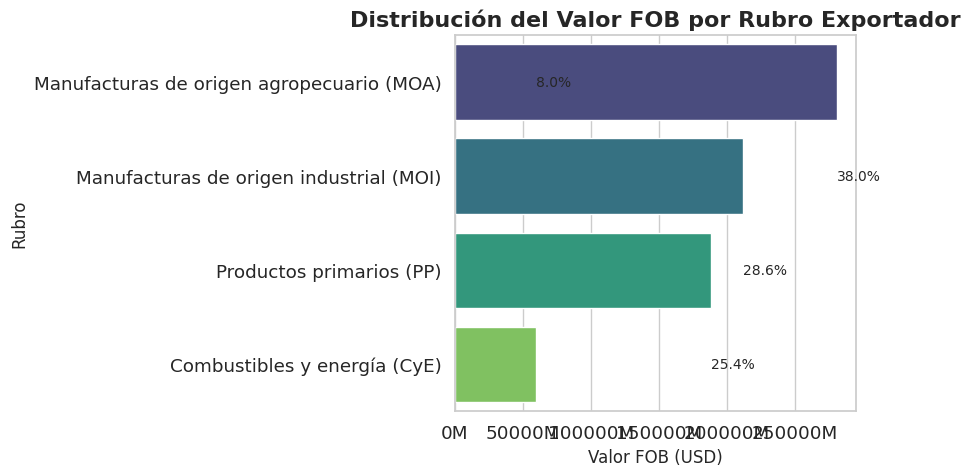

/tmp/ipython-input-2681177683.py:84: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



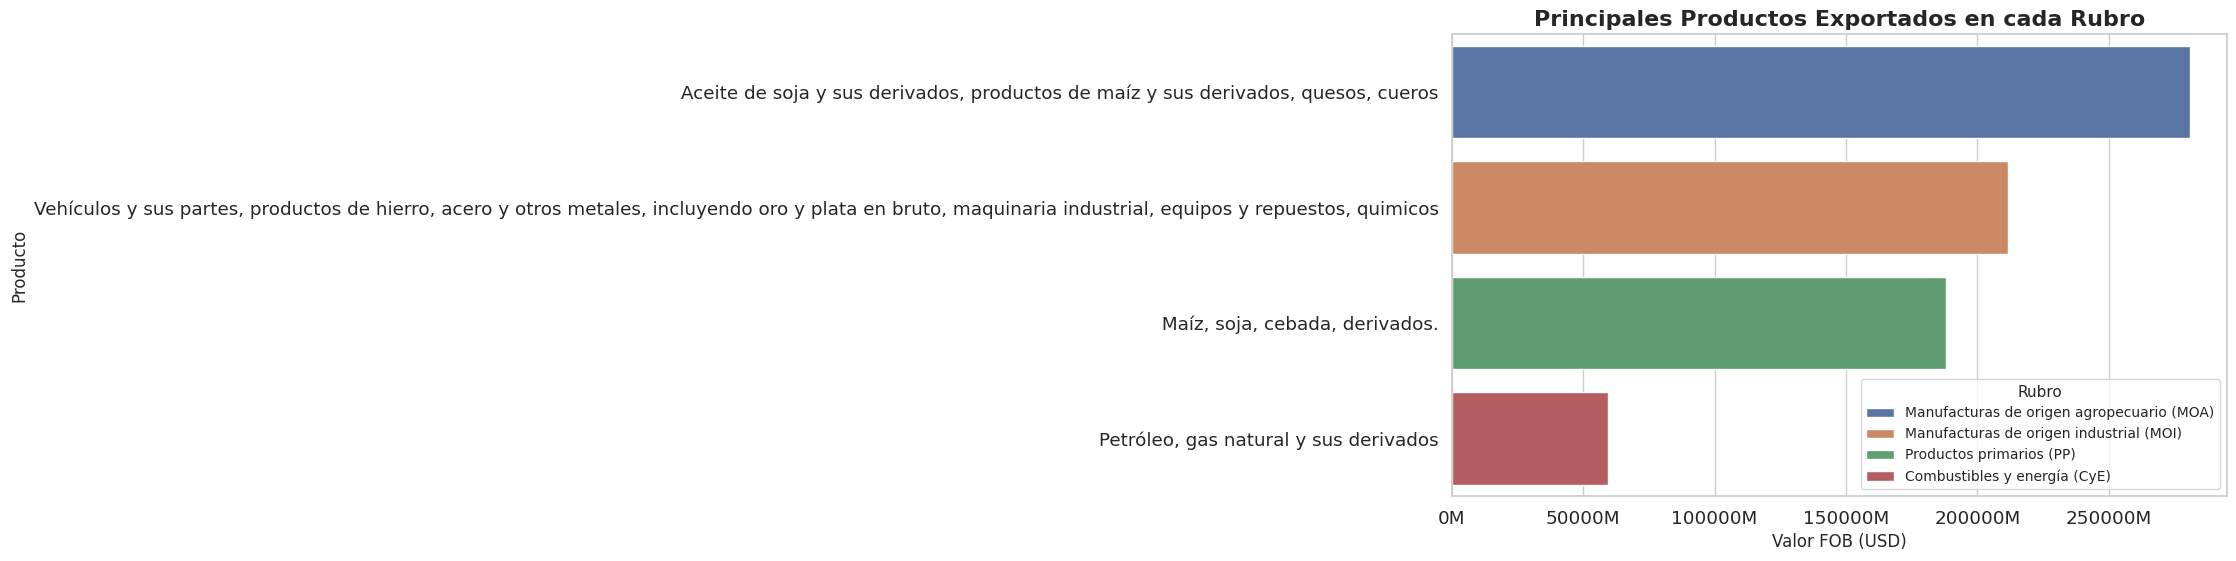

In [149]:

# --------------------------------
# EXPORTACIONES POR RUBRO Y PRODUCTO
# Formulación
# --------------------------------

df_rubro_producto = (
    df.groupby(['Rubro', 'tipo_Producto'])['FOB_dólar']
    .sum()
    .reset_index()
    .sort_values('FOB_dólar', ascending=False)
)

# --------------------------------
# Gráficas
# --------------------------------

df_top_rubros = (
    df.groupby('Rubro')['FOB_dólar']
    .sum()
    .reset_index()
    .sort_values('FOB_dólar', ascending=False)
)

total_fob = df_top_rubros['FOB_dólar'].sum()
df_top_rubros['Porcentaje'] = df_top_rubros['FOB_dólar'] / total_fob * 100

# Gráfico
plt.figure(figsize=(9,5))
sns.barplot(
    data=df_top_rubros,
    x='FOB_dólar',
    y='Rubro',
    palette='viridis'
)

# Etiquetas de porcentaje
for i, row in df_top_rubros.iterrows():
    plt.text(
        row['FOB_dólar'],
        i,
        f"{row['Porcentaje']:.1f}%",
        va='center',
        fontsize=10
    )

plt.title('Distribución del Valor FOB por Rubro Exportador', fontsize=16, weight='bold')
plt.xlabel('Valor FOB (USD)', fontsize=12)
plt.ylabel('Rubro', fontsize=12)

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.0f}M')
)

plt.tight_layout()
plt.show()

df_top_productos = (
    df.groupby(['Rubro', 'tipo_Producto'])['FOB_dólar']
    .sum()
    .reset_index()
    .sort_values('FOB_dólar', ascending=False)
    .groupby('Rubro')
    .head(2)
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=df_top_productos,
    x='FOB_dólar',
    y='tipo_Producto',
    hue='Rubro',
    dodge=False
)

plt.title('Principales Productos Exportados en cada Rubro', fontsize=16, weight='bold')
plt.xlabel('Valor FOB (USD)', fontsize=12)
plt.ylabel('Producto', fontsize=12)

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.0f}M')
)

plt.legend(title='Rubro', fontsize=10, title_fontsize=11)
plt.tight_layout()
plt.show()


#####**Conclusión**

El análisis evidencia que las exportaciones argentinas durante el período estudiado se encuentran altamente concentradas en pocos rubros. Las Manufacturas de Origen Agropecuario (MOA) y las Manufacturas de Origen Industrial (MOI) explican la mayor parte del valor FOB total, seguidas a mayor distancia por los Productos Primarios y el sector de Combustibles y Energía.

Esta concentración se refuerza al analizar los productos específicos dentro de cada rubro. En el caso del sector agroindustrial, los derivados de la soja y del maíz concentran una proporción significativa del valor exportado, mientras que en el rubro industrial destacan productos vinculados a la metalurgia, la maquinaria y la industria automotriz.

En conjunto, los resultados muestran un perfil exportador especializado, donde un número reducido de rubros y productos actúan como principales generadores de divisas. Si bien esta especialización puede reflejar ventajas comparativas, también sugiere una exposición del comercio exterior argentino a variaciones en la demanda internacional y en los precios de estos productos clave.

###*¿Qué provincias y regiones concentran el mayor volumen exportador?*

Teniendo información sobre cuales son las materias y materiales que se exportaron durante la última década, es necesario conocer cuales fueron las provincias que contribuyeron a este movimiento de comercio internacional.


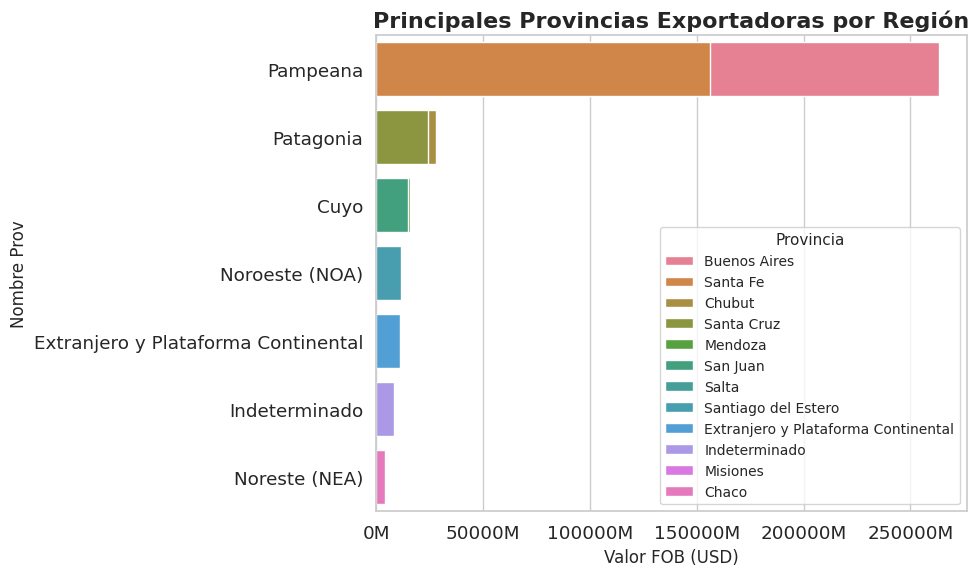

In [150]:
# --------------------------------
# REGIONES EXPORTADORAS
# Formulación
# --------------------------------

df_regiones_exportadoras = (
    df.groupby(['Nombre_Región', 'Nombre Prov'])['FOB_dólar']
    .sum()
    .reset_index()
    .sort_values('FOB_dólar', ascending=False)
)

# --------------------------------
# Gráficas
# --------------------------------

df_top_exportadores = (
    df.groupby('Nombre_Región')['FOB_dólar']
    .sum()
    .head(10)
    .reset_index()
    .sort_values('FOB_dólar', ascending=False)
)

total_fob_exp = df_top_exportadores['FOB_dólar'].sum()
df_top_exportadores['Porcentaje'] = df_top_exportadores['FOB_dólar'] / total_fob_exp * 100

#Por Provincia
df_top_provincias = (
    df.groupby(['Nombre_Región', 'Nombre Prov'])['FOB_dólar']
    .sum()
    .reset_index()
    .sort_values('FOB_dólar', ascending=False)
    .groupby('Nombre_Región')
    .head(2)
)

# Graficos TreeMap

paleta = px.colors.sequential.Teal

fig = px.treemap(
    df_top_provincias,
    path=['Nombre_Región', 'Nombre Prov'],
    values='FOB_dólar',
    hover_data={'FOB_dólar': ':,.0f'},
    color_discrete_sequence=paleta,
    title='Top Provincias Exportadoras por Región'
)

fig.update_traces(
    textinfo='label+percent parent'
)

fig.show()


plt.figure(figsize=(10,6))
sns.barplot(
    data=df_top_provincias,
    x='FOB_dólar',
    y='Nombre_Región',
    hue='Nombre Prov',
    dodge=False
)

plt.title('Principales Provincias Exportadoras por Región', fontsize=16, weight='bold')
plt.xlabel('Valor FOB (USD)', fontsize=12)
plt.ylabel('Nombre Prov', fontsize=12)

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.0f}M')
)

plt.legend(title='Provincia', fontsize=10, title_fontsize=11)
plt.tight_layout()
plt.show()

#Por Region

top_prov = (
    df.groupby(["Nombre_Región", "Nombre Prov"])["FOB_dólar"]
      .sum()
      .reset_index()
)

top_prov = top_prov.sort_values(["Nombre_Región", "FOB_dólar"], ascending=[True, False])
top_prov = top_prov.groupby("Nombre_Región").head(5)



###**Conclusión**

#####*Concentración geográfica de las exportaciones*

El análisis evidencia una marcada concentración del volumen exportador en la Región Pampeana, que se posiciona ampliamente por encima del resto de las regiones del país. Dentro de esta región, la provincia de Buenos Aires lidera el ranking exportador, seguida por Santa Fe, lo que refleja el peso estructural de este corredor productivo y logístico en el comercio exterior argentino.

En un segundo nivel se ubica la Patagonia, impulsada principalmente por las provincias de Chubut y Santa Cruz, asociadas a exportaciones vinculadas a energía y recursos naturales. La región de Cuyo también presenta una participación relevante, con Mendoza y San Juan como principales aportantes.

Por el contrario, las regiones del NOA y NEA muestran una menor participación relativa en el volumen total exportado, lo que sugiere una estructura exportadora concentrada tanto a nivel regional como provincial. En conjunto, estos resultados confirman que una porción significativa de las exportaciones argentinas se origina en un número reducido de provincias, principalmente localizadas en la región central del país.

####**¿En qué años y meses se registran los picos de exportación?**

Despues de analizar las provincias y regiones con mayor participación en la exportación, ahora buscamos identificar los periodos de tiempo de mayor flujo de la participación de Argentina en el comercio exterior.


In [151]:
# --------------------------------
# CRONOLOGIA DE EXPORTACIÓN
# Formulación
# --------------------------------

# Anual
df_anual = (
    df.groupby(['Año', 'Rubro'])['FOB_dólar']
    .sum()
    .reset_index()
)

df_max_rubro = df_anual.loc[df_anual.groupby('Año')['FOB_dólar'].idxmax()]
df_anual['FOB_dólar_text'] = df_anual['FOB_dólar'].apply(formato_millones)

# --------------------------------
# Gráficos
# --------------------------------

# Lineas Ganancia por Año

fig = px.line(df_anual.groupby('Año')['FOB_dólar'].sum().reset_index(),
              x='Año', y='FOB_dólar', title='Exportaciones totales por año')

# Barras apiladas Rubro

paleta = px.colors.sequential.Teal

fig = px.bar(
    df_anual,
    x='Año',
    y='FOB_dólar',
    color='Rubro',
    color_discrete_sequence=paleta,
    text='FOB_dólar_text',
    title='Exportaciones por rubro en la última década',
    labels={'FOB_dólar':'Exportaciones (USD)'}
)

#Lineas de Ganancia por Años

df_total = df.groupby('Año')['FOB_dólar'].sum().reset_index()
fig.add_scatter(
    x=df_total['Año'],
    y=df_total['FOB_dólar'],
    mode='lines+markers',
    name='Total',
    line=dict(color='black', width=2)
)

# Diseño de Barras Apiladas

fig.update_layout(
    barmode='stack',
    yaxis=dict(title='FOB en USD', tickformat = ",.2s"),
    xaxis=dict(title='Año')
)

fig.show()



###**Conclusión**

####*Identificación de picos temporales de exportación*

La evolución temporal de las exportaciones muestra que los mayores picos de valor FOB se concentran en los años 2021 y 2022, período en el cual se observa un crecimiento significativo respecto de los años previos. Este comportamiento sugiere una combinación de mayor volumen exportado y/o mejores precios internacionales en dicho intervalo.

A nivel intraanual, el análisis mensual evidencia una estacionalidad moderada, con incrementos recurrentes en determinados meses asociados al calendario productivo, especialmente en los rubros vinculados al sector agroindustrial. Estos patrones indican que, si bien existen fluctuaciones a lo largo del año, los picos más relevantes se explican principalmente por dinámicas anuales y no únicamente por variaciones mensuales aisladas.

###**¿Cómo evolucionaron las ganancias en dólares a lo largo del tiempo?**

Si bien el análisis previo permitió obtener una visión general de la evolución de las exportaciones, resulta conveniente incorporar una visualización más detallada que permita desagregar el comportamiento de los distintos rubros a lo largo del tiempo. Dado que el período analizado abarca varios años y contempla múltiples fuentes de ingreso, se optó por segmentar el flujo de ganancias de manera anual.

In [152]:
# --------------------------------
# CASCADA DE EVOLUCIÓN DE GANANCIAS
# Formulación
# --------------------------------

from plotly.subplots import make_subplots #biblioteca para Waterfall

ultimos_10_anios = sorted(df['Año'].unique())[-11:]

# --------------------------------
# Gráfico
# --------------------------------

# Segmentación por año
fig = make_subplots(
    rows=len(ultimos_10_anios), cols=1,
    shared_xaxes=False,
    subplot_titles=[f"Año {a}" for a in ultimos_10_anios]
)

# WaterFall por Año
for i, anio in enumerate(ultimos_10_anios, start=1):
    df_anio = df[df['Año']==anio].groupby('Rubro')['FOB_dólar'].sum().reset_index()

    fig.add_trace(
        go.Waterfall(
            name=f"{anio}",
            x=df_anio['Rubro'],
            y=df_anio['FOB_dólar'],
            measure=["relative"]*len(df_anio),
            text=df_anio['FOB_dólar'].apply(lambda x: f"${x:,.0f}"),
            textposition="outside",
            decreasing={"marker":{"color":"tomato"}},
            increasing={"marker":{"color":"teal"}},
            totals={"marker":{"color":"grey"}},
        ),
        row=i, col=1
    )

fig.update_layout(
    height=400*len(ultimos_10_anios),
    title_text="Contribución de rubros a las exportaciones por año (última década)",
    showlegend=False,
)

fig.show()

###**Conclusión**

####*Predominancia del Agro*

La evolución de las ganancias en valor FOB muestra un crecimiento general, con oscilaciones interanuales vinculadas a volúmenes y precios internacionales, destacándose incrementos significativos desde 2020 impulsados por los rubros tradicionales del comercio exterior argentino.

Los productos primarios y las manufacturas agropecuarias dominan la generación de divisas, mientras que los rubros industriales presentan mayor variabilidad y crecimiento moderado, indicando que el aumento de las ganancias responde a la expansión de sectores históricamente predominantes y no a un cambio estructural en la matriz exportadora.

####**¿Qué patrones o tendencias se pueden identificar en la distribución de los bienes exportados?**

Esta pregunta busca identificar patrones de concentración, persistencia y variabilidad en la exportación de bienes a lo largo del tiempo, analizando cuáles productos mantienen una demanda sostenida y cuáles presentan fluctuaciones más pronunciadas entre los distintos años.


Producto más exportado:  Aceite de soja y sus derivados, productos de maíz y sus derivados, quesos, cueros con $280,814,308,478
Producto con mayor crecimiento: Petróleo, gas natural y sus derivados (301.6%)


/tmp/ipython-input-4035939848.py:54: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



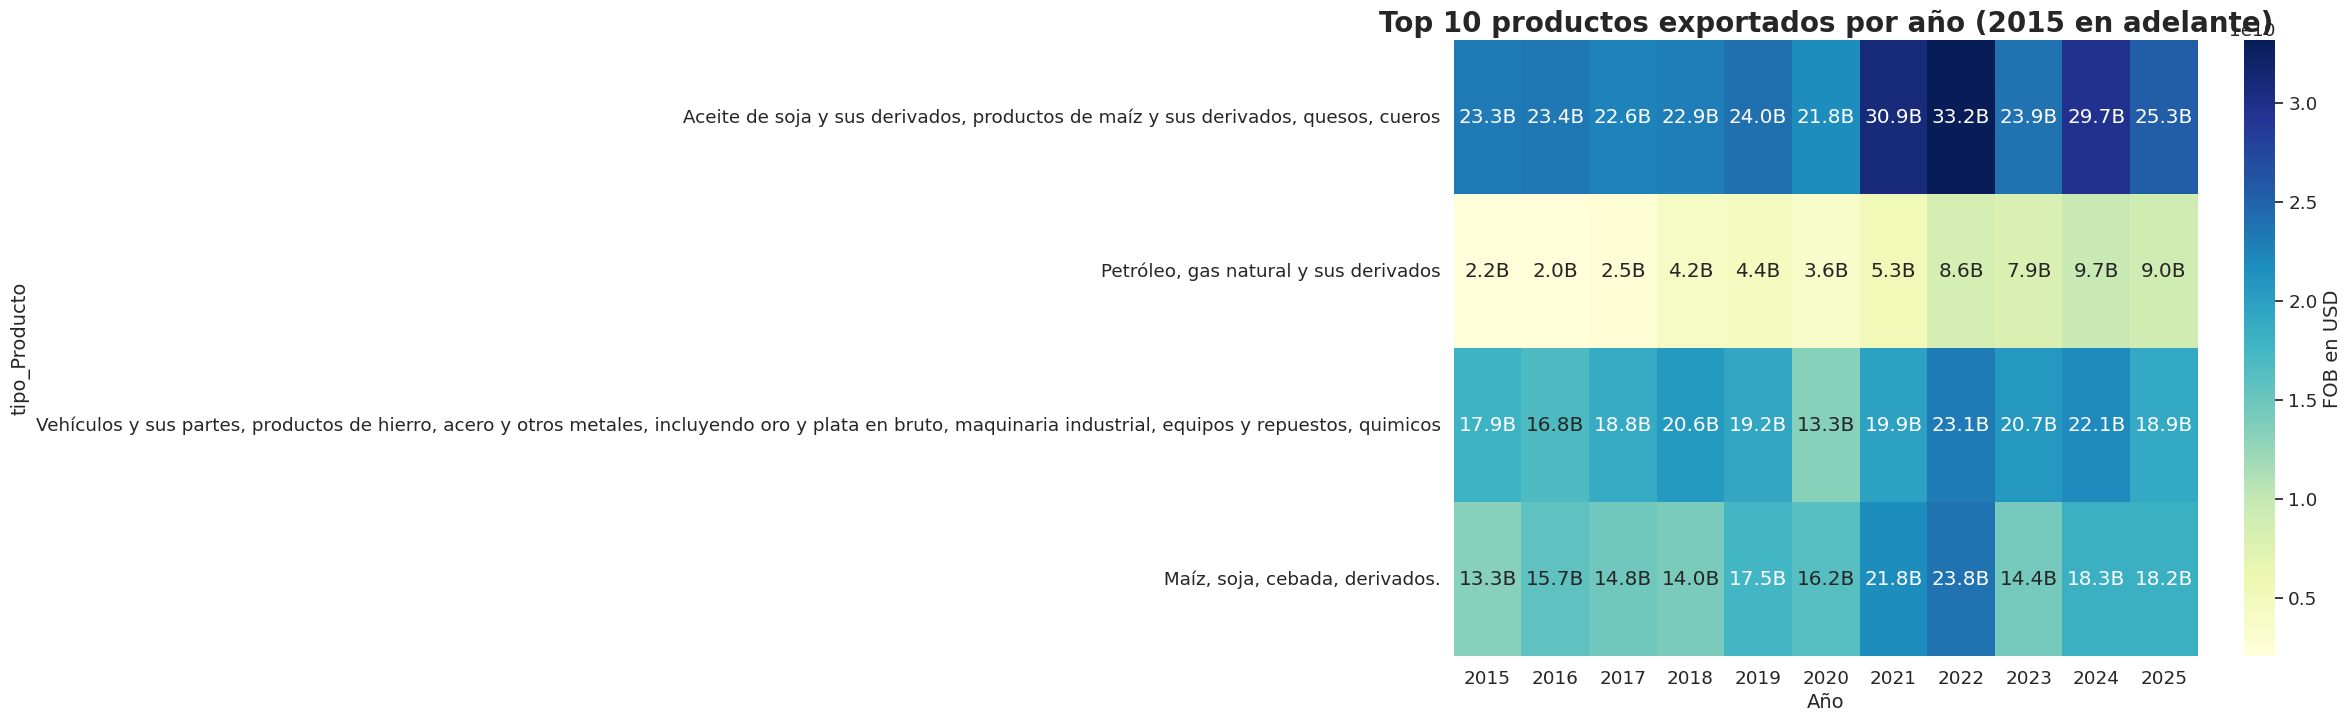

In [171]:
# ----------------------------------------------
# TENDENCIAS Y PATRONES EN LA EXPORTACIÓN
# KPIs
# ----------------------------------------------

# Producto que más exportó
df_ultimos10 = df[df['Año'] >= 2015]
producto_top = df.groupby('tipo_Producto')['FOB_dólar'].sum().idxmax()
valor_top = df.groupby('tipo_Producto')['FOB_dólar'].sum().max()

# Producto con mayor crecimiento entre el primer y último año
df_prod_anual = df.groupby(['Año','tipo_Producto'])['FOB_dólar'].sum().reset_index()
df_inicio = df_prod_anual[df_prod_anual['Año']==df_prod_anual['Año'].min()]
df_final  = df_prod_anual[df_prod_anual['Año']==df_prod_anual['Año'].max()]
crecimiento = (df_final.set_index('tipo_Producto')['FOB_dólar'] - df_inicio.set_index('tipo_Producto')['FOB_dólar']) / df_inicio.set_index('tipo_Producto')['FOB_dólar'] * 100
producto_crec = crecimiento.idxmax()
crec_val = crecimiento.max()

print(f"Producto más exportado: {producto_top} con ${valor_top:,.0f}")
print(f"Producto con mayor crecimiento: {producto_crec} ({crec_val:.1f}%)")

df_top_productos = df.groupby(['Año','tipo_Producto'])['FOB_dólar'].sum().reset_index()
top10_productos = df_top_productos.groupby('tipo_Producto')['FOB_dólar'].sum().nlargest(10).index
df_top_productos = df_top_productos[df_top_productos['tipo_Producto'].isin(top10_productos)]
df_top_productos['FOB_dólar_text'] = df_top_productos['FOB_dólar'].apply(formato_millones)

# --------------------------------
# Gráfico
# --------------------------------

#Heat Map

top_productos = df_ultimos10.groupby('tipo_Producto')['FOB_dólar'].sum().nlargest(10).index
df_top = df_ultimos10[df_ultimos10['tipo_Producto'].isin(top_productos)]

# Agrupar por Producto y Año para evitar duplicados
df_agg = df_top.groupby(['tipo_Producto', 'Año'])['FOB_dólar'].sum().reset_index()

# Pivot para heatmap
heatmap_data = df_agg.pivot(index='tipo_Producto', columns='Año', values='FOB_dólar')

# Función para abreviar números
def format_large(x):
    if x >= 1e9:
        return f"{x/1e9:.1f}B"
    elif x >= 1e6:
        return f"{x/1e6:.1f}M"
    elif x >= 1e3:
        return f"{x/1e3:.1f}K"
    else:
        return f"{x:.0f}"

# Crear DataFrame de strings para anotaciones
annot_data = heatmap_data.applymap(format_large)

# Graficar
plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data, cmap="YlGnBu",annot=annot_data, fmt="", cbar_kws={'label':'FOB en USD'})
plt.title("Top 10 productos exportados por año (2015 en adelante)")
plt.show()


###**Conclusión**
####*Patrones en la distribución de los bienes exportados*


Para abordar esta cuestión, se utilizó un gráfico de calor, dado que permite visualizar de manera simultánea la evolución temporal y la magnitud del valor exportado por producto. La combinación entre la clasificación por año y tipo de producto, junto con la escala cromática, facilita la identificación de patrones de concentración y estabilidad en la demanda externa.

Los resultados muestran que los productos vinculados al sector agropecuario y sus derivados lideran de forma consistente el valor exportado a lo largo del período analizado, evidenciando una demanda sostenida en el tiempo. En particular, los complejos asociados a la soja y al maíz presentan niveles elevados de exportación en prácticamente todos los años, con picos bien definidos en los períodos de mayor actividad.

En contraste, otros productos exhiben una mayor variabilidad interanual, lo que sugiere una dependencia más marcada de factores coyunturales. En conjunto, el análisis confirma un patrón exportador concentrado en bienes primarios y manufacturas de origen agropecuario, que constituyen el núcleo del comercio exterior argentino.

##**En sintesis...**

A partir del análisis de los datos de exportaciones argentinas correspondientes al período estudiado, fue posible responder de manera consistente a las principales preguntas planteadas al inicio del proyecto y contrastar las hipótesis preliminares con evidencia empírica.

En primer lugar, los resultados confirman que la estructura exportadora argentina se encuentra fuertemente concentrada en el *sector agropecuario* y sus derivados, destacándose productos como la *soja, el maíz, la cebada y los complejos cárnicos*. Tanto los productos primarios como las manufacturas de origen agropecuario lideran el valor total exportado, lo que valida la hipótesis inicial que anticipaba un claro protagonismo del agro en el comercio exterior.

Desde el punto de vista geográfico, se observa una alta concentración del volumen exportador en la **Región Pampeana**, con la provincia de *Buenos Aires* como principal actor, seguida por *Santa Fe y Córdoba*. Esta distribución confirma la percepción inicial basada en la visibilidad mediática de estas provincias, mientras que regiones como el **NOA** y **NEA** presentan una participación considerablemente menor, evidenciando asimetrías regionales persistentes.

En términos temporales, el análisis permitió identificar *picos de exportación* concentrados en determinados años, especialmente en los más *recientes del período*, así como una estacionalidad moderada a nivel mensual, asociada al calendario productivo del sector agroindustrial. Si bien la hipótesis inicial ubicaba los mayores niveles de exportación en los *primeros meses del año,* los datos muestran que **las variaciones anuales** tienen un peso mayor que las fluctuaciones mensuales aisladas.

Respecto de la evolución de las ganancias en dólares, los resultados indican un crecimiento sostenido del valor *FOB exportado*, particularmente a partir de 2020. Este aumento no parece responder a una *diversificación de la canasta exportadora*, sino a una **mayor valorización y consolidación de los rubros tradicionales**, lo que coincide parcialmente con la hipótesis que vinculaba este fenómeno con el contexto global de la pandemia, aunque dicho vínculo requeriría un *análisis adicional* para ser confirmado.

Finalmente, el estudio de los patrones de distribución de los bienes exportados revela una persistencia estructural en la **especialización en materias primas y bienes de bajo nivel de industrialización**, con una participación relativamente menor de productos industriales como maquinaria o repuestos. Este hallazgo refuerza la idea de que *las ventajas comparativas del país continúan ancladas en sus recursos naturales y condiciones productivas*, sin evidenciarse cambios significativos hacia una matriz exportadora más diversificada.

*En síntesis*, el proyecto permite concluir que las exportaciones argentinas mantienen una *estructura concentrada* tanto a nivel sectorial como geográfico, con un *crecimiento del valor exportado* en dólares que no implica, al menos en el período analizado, una transformación estructural del perfil exportador del país.